# Pipeline 5: Incident Early Warning

## 1) Problem Framing

**Business question:** At intake, which newly admitted residents are at elevated risk of self-harm or runaway attempts?

**Who cares and why:** Safehouse staff and social workers need early identification of at-risk residents so they can assign proactive monitoring and intervention *immediately upon admission*. This is the highest-stakes prediction in the system — a missed self-harm warning for a vulnerable minor could have catastrophic consequences.

### Approach

This pipeline trains **two separate classifiers** (one per target):
- **Self-harm risk** (`has_self_harm`)
- **Runaway risk** (`has_runaway`)

Both are **predictive** models, complemented by an **explanatory companion model** (logistic regression) to understand which intake factors drive risk.

### Prediction vs. Explanation

The primary models prioritize **recall** — we want to catch as many at-risk residents as possible, even at the cost of some false alarms. The explanatory model helps staff understand *why* certain residents are flagged, which is critical for trust and appropriate intervention design.

### Error Cost Discussion

- **False positive** (flag a resident who doesn't go on to have an incident): Extra monitoring is assigned unnecessarily — costs staff time but causes no harm. May even be beneficial as a precaution.
- **False negative** (miss a resident who later self-harms or runs away): Potentially catastrophic — a vulnerable minor goes without needed intervention.
- **Implication:** We tune aggressively toward **recall** by lowering the classification threshold (0.35 instead of 0.5). We accept lower precision to minimize missed cases.

### Constraint

Models must work at the **moment of admission** — before any counseling sessions, health records, or visit data exists. Only **intake-available features** (demographics, trauma history, case category, risk level) are used.

### Dataset Limitation

- ~60 residents, ~12 self-harm cases, ~17 runaway cases
- Very small sample; results should be treated as directional
- Stratified splits are essential to maintain class proportions

> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
# 2) Data Acquisition and Preparation
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import json as _json
import os
from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, precision_recall_curve,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Database connection ──────────────────────────────────────────────────────
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in ['.env', 'ml/.env']:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)


def fetch_table(table_name):
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# ── Feature engineering helpers ──────────────────────────────────────────────
RISK_MAP = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}

TRAUMA_WEIGHTS = {
    "sub_cat_sexual_abuse": 3.0,
    "sub_cat_trafficked": 3.0,
    "sub_cat_osaec": 3.0,
    "sub_cat_physical_abuse": 2.0,
    "sub_cat_child_labor": 2.0,
    "sub_cat_at_risk": 1.0,
}

TARGET_SELF_HARM = "has_self_harm"
TARGET_RUNAWAY = "has_runaway"


def _to_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    normalized = (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False})
    )
    return normalized.fillna(False).astype(bool)


def _safe_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)


def build_feature_frame(
    residents: pd.DataFrame,
    *,
    case_category_values: Iterable[str] | None = None,
    now_utc: datetime | None = None,
) -> pd.DataFrame:
    """Build intake-only resident feature frame (one row per resident)."""
    if now_utc is None:
        now_utc = datetime.now(timezone.utc)

    df = residents.copy()
    df["date_of_birth"] = _safe_datetime(df.get("date_of_birth", pd.Series(index=df.index)))
    df["date_of_admission"] = _safe_datetime(df.get("date_of_admission", pd.Series(index=df.index)))

    age = ((df["date_of_admission"] - df["date_of_birth"]).dt.days / 365.25).clip(lower=0)
    df["age_at_admission"] = age.fillna(0)
    df["initial_risk_num"] = df.get("initial_risk_level").map(RISK_MAP).fillna(0).astype(float)

    trauma_score = pd.Series(0.0, index=df.index)
    for col, weight in TRAUMA_WEIGHTS.items():
        if col in df.columns:
            trauma_score += _to_bool(df[col]).astype(float) * weight
    df["trauma_severity_score"] = trauma_score

    family_cols = [c for c in df.columns if c.startswith("family_")]
    if family_cols:
        family_bool = pd.concat([_to_bool(df[c]) for c in family_cols], axis=1)
        df["family_vulnerability_score"] = family_bool.sum(axis=1)
    else:
        df["family_vulnerability_score"] = 0.0

    bool_features = [
        "sub_cat_sexual_abuse",
        "sub_cat_trafficked",
        "sub_cat_osaec",
        "sub_cat_physical_abuse",
        "has_special_needs",
        "is_pwd",
    ]
    for col in bool_features:
        if col in df.columns:
            df[col] = _to_bool(df[col]).astype(int)
        else:
            df[col] = 0

    df["case_category"] = df.get("case_category", pd.Series(index=df.index, dtype=object)).fillna("None").astype(str)
    case_dummies = pd.get_dummies(df["case_category"], prefix="case_category", dtype=int)
    if case_category_values:
        expected = [f"case_category_{cat}" for cat in case_category_values]
        for col in expected:
            if col not in case_dummies:
                case_dummies[col] = 0
        case_dummies = case_dummies[expected]

    keep_cols = [
        "resident_id",
        "age_at_admission",
        "initial_risk_num",
        "trauma_severity_score",
        "family_vulnerability_score",
        *bool_features,
    ]
    out = pd.concat([df[keep_cols], case_dummies], axis=1)
    out.columns = pd.Index([str(c) for c in out.columns])
    return out.fillna(0)


def build_targets(residents: pd.DataFrame, incident_reports: pd.DataFrame) -> pd.DataFrame:
    """Build resident-level self-harm/runaway binary targets."""
    base = residents[["resident_id"]].drop_duplicates().copy()
    if incident_reports.empty:
        base[TARGET_SELF_HARM] = 0
        base[TARGET_RUNAWAY] = 0
        return base

    inc = incident_reports.copy()
    inc["incident_type"] = inc.get("incident_type", pd.Series(index=inc.index, dtype=object)).fillna("").astype(str)

    selfharm_ids = set(inc.loc[inc["incident_type"].eq("SelfHarm"), "resident_id"].dropna().astype(int).tolist())
    runaway_ids = set(inc.loc[inc["incident_type"].eq("RunawayAttempt"), "resident_id"].dropna().astype(int).tolist())

    base[TARGET_SELF_HARM] = base["resident_id"].astype(int).isin(selfharm_ids).astype(int)
    base[TARGET_RUNAWAY] = base["resident_id"].astype(int).isin(runaway_ids).astype(int)
    return base


def build_training_frame() -> pd.DataFrame:
    """Return one row per resident with intake features + both incident targets."""
    residents = fetch_table("residents")
    incidents = fetch_table("incident_reports")

    X = build_feature_frame(residents)
    y = build_targets(residents, incidents)
    train_df = X.merge(y, on="resident_id", how="left").fillna(0)
    return train_df


# ── Model artifact paths ────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "models").exists() else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_DIR = MODELS_DIR / "incident-early-warning"
MODEL_PATH = MODEL_DIR / "model.sav"
MODEL_RUNS_PATH = MODEL_DIR / "model.json"
MODEL_NAME = "incident-early-warning"

In [2]:
df = build_training_frame()

feature_cols = [
    c for c in df.columns
    if c not in {"resident_id", "has_self_harm", "has_runaway"}
]

X = df[feature_cols].copy()
y_selfharm = df["has_self_harm"].astype(int)
y_runaway = df["has_runaway"].astype(int)

print(f"Total residents: {len(df)}")
print(f"Features: {len(feature_cols)}")
print(f"\nSelf-harm distribution:\n{y_selfharm.value_counts()}")
print(f"Self-harm rate: {y_selfharm.mean():.1%}")
print(f"\nRunaway distribution:\n{y_runaway.value_counts()}")
print(f"Runaway rate: {y_runaway.mean():.1%}")
print(f"\nFeature list: {feature_cols}")

Total residents: 60
Features: 14

Self-harm distribution:
has_self_harm
0    48
1    12
Name: count, dtype: int64
Self-harm rate: 20.0%

Runaway distribution:
has_runaway
0    39
1    21
Name: count, dtype: int64
Runaway rate: 35.0%

Feature list: ['age_at_admission', 'initial_risk_num', 'trauma_severity_score', 'family_vulnerability_score', 'sub_cat_sexual_abuse', 'sub_cat_trafficked', 'sub_cat_osaec', 'sub_cat_physical_abuse', 'has_special_needs', 'is_pwd', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected', 'case_category_Surrendered']


In [3]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 60, Features: 14

=== Outlier Check (numeric features) ===
  trauma_severity_score: 2 IQR outliers (3.3%)
  family_vulnerability_score: 29 IQR outliers (48.3%)
  sub_cat_sexual_abuse: 15 IQR outliers (25.0%)
  sub_cat_trafficked: 11 IQR outliers (18.3%)
  sub_cat_osaec: 8 IQR outliers (13.3%)
  sub_cat_physical_abuse: 7 IQR outliers (11.7%)
  has_special_needs: 6 IQR outliers (10.0%)
  is_pwd: 3 IQR outliers (5.0%)
  case_category_Foundling: 11 IQR outliers (18.3%)
  case_category_Neglected: 10 IQR outliers (16.7%)

=== Feature Summary ===


,count,mean,std,min,25%,50%,75%,max
age_at_admission,60.0,13.903445,2.788593,8.76386,12.019165,14.892539,15.183436,17.700205
initial_risk_num,60.0,2.216667,0.903696,1.00000,2.000000,2.000000,3.000000,4.000000
trauma_severity_score,60.0,2.500000,2.281094,0.00000,0.000000,3.000000,3.250000,9.000000
family_vulnerability_score,60.0,1.083333,0.907439,0.00000,0.750000,1.000000,1.000000,4.000000
sub_cat_sexual_abuse,60.0,0.250000,0.436667,0.00000,0.000000,0.000000,0.250000,1.000000
sub_cat_trafficked,60.0,0.183333,0.390205,0.00000,0.000000,0.000000,0.000000,1.000000
sub_cat_osaec,60.0,0.133333,0.342803,0.00000,0.000000,0.000000,0.000000,1.000000
sub_cat_physical_abuse,60.0,0.116667,0.323732,0.00000,0.000000,0.000000,0.000000,1.000000
has_special_needs,60.0,0.100000,0.302532,0.00000,0.000000,0.000000,0.000000,1.000000
is_pwd,60.0,0.050000,0.219784,0.00000,0.000000,0.000000,0.000000,1.000000


## 3) Exploration (Ch. 6-8)

We examine distributions of intake features, their relationship with both targets, and key risk factors identified in domain research:
- 100% of Critical/High risk residents at intake have had incidents
- Sexual abuse survivors: ~67% self-harm rate
- Trafficked residents: ~64% runaway rate

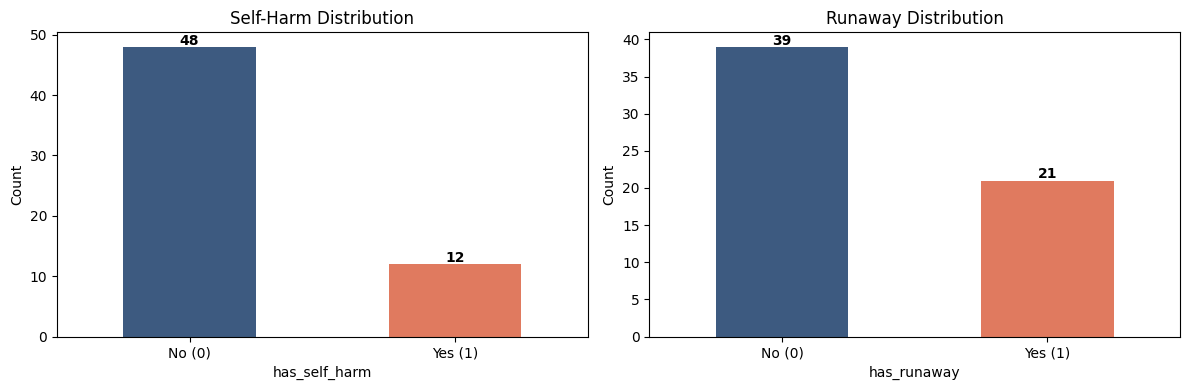

In [4]:
# 3a) Target distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, target, name in [(axes[0], y_selfharm, "Self-Harm"), (axes[1], y_runaway, "Runaway")]:
    counts = target.value_counts()
    counts.plot(kind="bar", color=["#3d5a80", "#e07a5f"], ax=ax)
    ax.set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
    ax.set_title(f"{name} Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

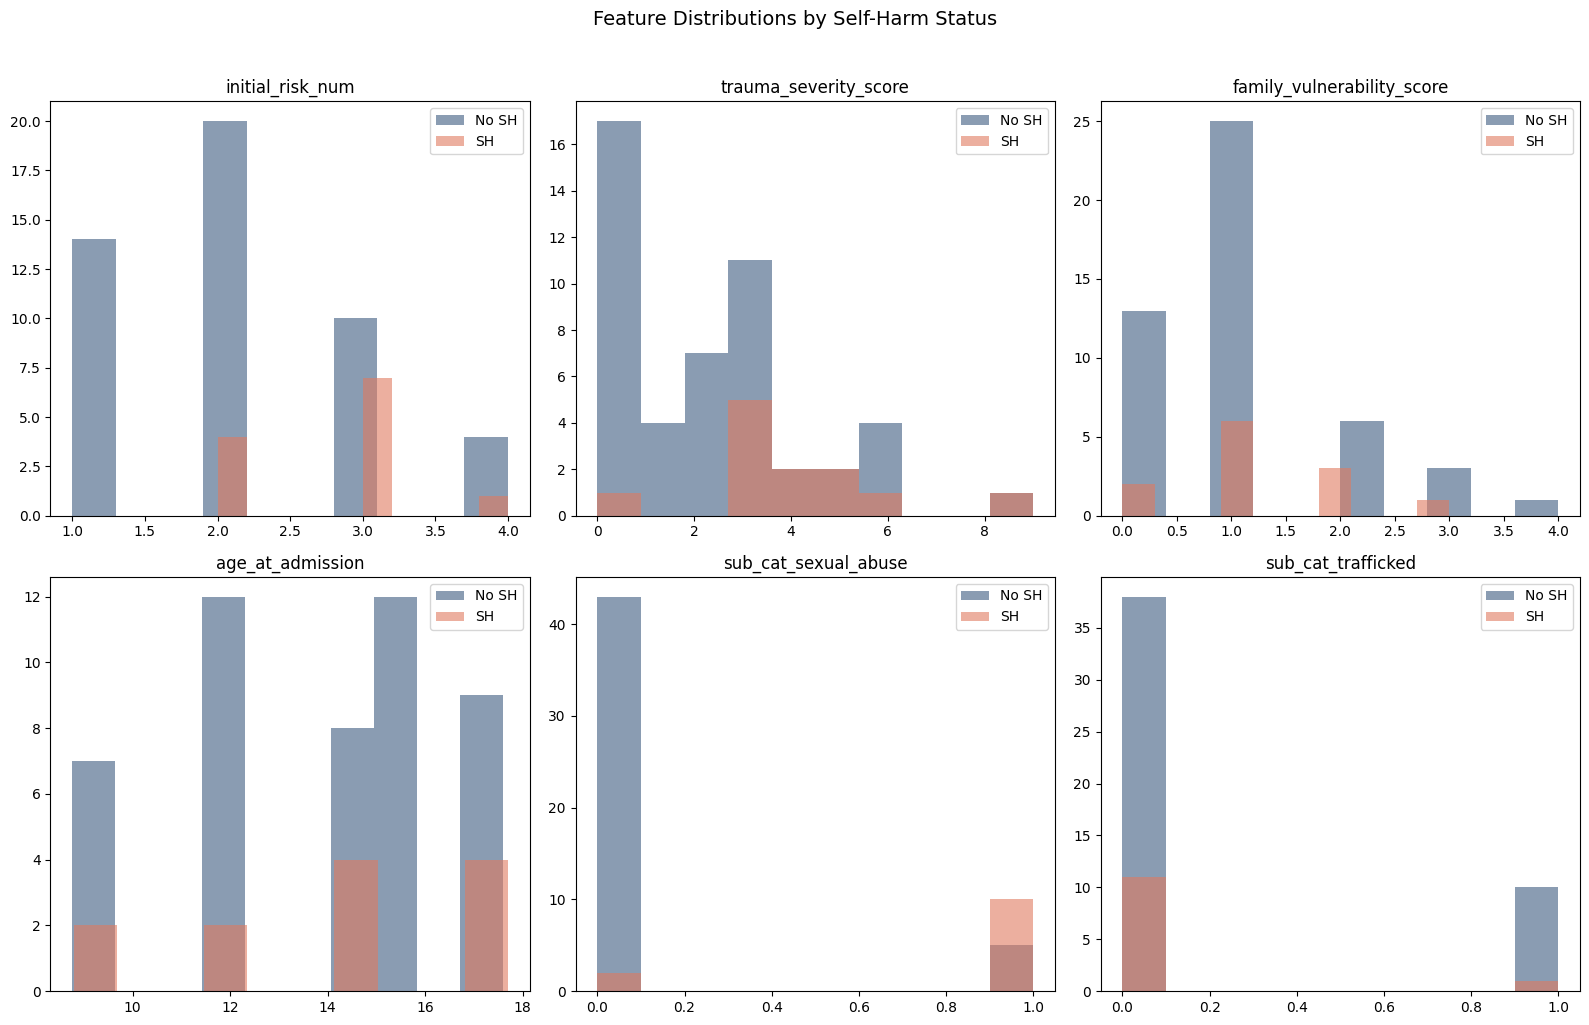

In [5]:
# 3b) Feature distributions — key intake features by self-harm status
key_features = ["initial_risk_num", "trauma_severity_score", "family_vulnerability_score",
                "age_at_admission", "sub_cat_sexual_abuse", "sub_cat_trafficked"]
available = [f for f in key_features if f in X.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(available):
    ax = axes[i]
    for label, color, lbl in [(0, "#3d5a80", "No SH"), (1, "#e07a5f", "SH")]:
        subset = X.loc[y_selfharm == label, feat].dropna()
        ax.hist(subset, bins=10, alpha=0.6, color=color, label=lbl)
    ax.set_title(feat)
    ax.legend()

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Self-Harm Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

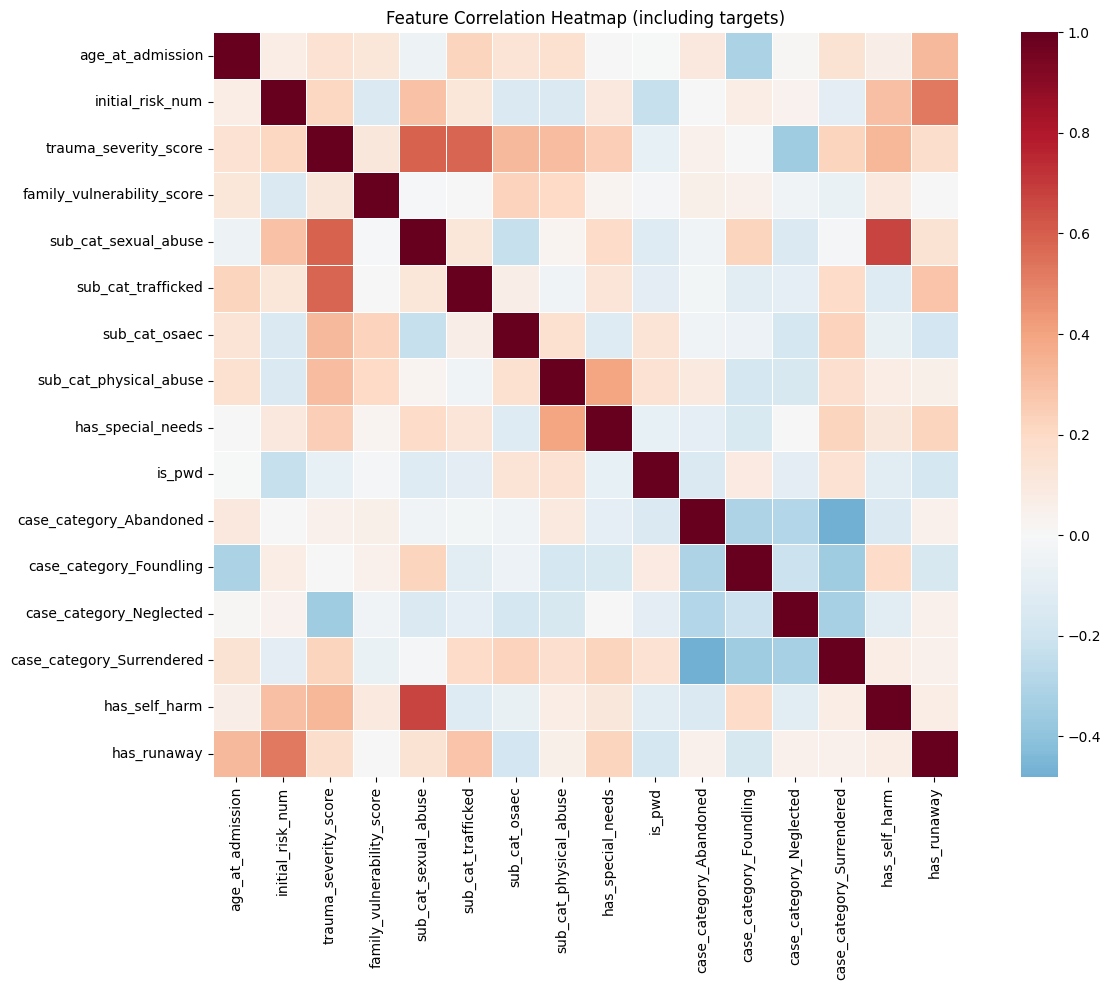

Top correlations with self-harm:
sub_cat_sexual_abuse       0.673575
trauma_severity_score      0.331564
initial_risk_num           0.297575
case_category_Foundling    0.193829
case_category_Abandoned   -0.145479
sub_cat_trafficked        -0.129219
is_pwd                    -0.114708
case_category_Neglected   -0.111803
Name: has_self_harm, dtype: float64

Top correlations with runaway:
initial_risk_num           0.524454
age_at_admission           0.320921
sub_cat_trafficked         0.284463
has_special_needs          0.221305
sub_cat_osaec             -0.185027
trauma_severity_score      0.177649
is_pwd                    -0.168345
case_category_Foundling   -0.167065
Name: has_runaway, dtype: float64


In [6]:
# 3c) Correlation heatmap with both targets
corr_df = df.drop(columns=["resident_id"], errors="ignore")
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_df.corr(numeric_only=True), cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Feature Correlation Heatmap (including targets)")
plt.tight_layout()
plt.show()

# Correlations with each target
print("Top correlations with self-harm:")
sh_corr = corr_df.corr(numeric_only=True)["has_self_harm"].drop(["has_self_harm", "has_runaway"], errors="ignore")
print(sh_corr.sort_values(key=abs, ascending=False).head(8))

print("\nTop correlations with runaway:")
rw_corr = corr_df.corr(numeric_only=True)["has_runaway"].drop(["has_self_harm", "has_runaway"], errors="ignore")
print(rw_corr.sort_values(key=abs, ascending=False).head(8))

In [7]:
# 3d) Risk factor analysis — self-harm rates by key binary indicators
binary_cols = [c for c in feature_cols if X[c].nunique() <= 2 and X[c].max() == 1]

print("Self-harm rate by binary intake feature:")
print("-" * 55)
for col in sorted(binary_cols):
    rate_yes = y_selfharm[X[col] == 1].mean() if (X[col] == 1).sum() > 0 else 0
    rate_no = y_selfharm[X[col] == 0].mean() if (X[col] == 0).sum() > 0 else 0
    n_yes = (X[col] == 1).sum()
    print(f"  {col:40s}  yes={rate_yes:.1%} (n={n_yes:2d})  no={rate_no:.1%}")

print("\nRunaway rate by binary intake feature:")
print("-" * 55)
for col in sorted(binary_cols):
    rate_yes = y_runaway[X[col] == 1].mean() if (X[col] == 1).sum() > 0 else 0
    rate_no = y_runaway[X[col] == 0].mean() if (X[col] == 0).sum() > 0 else 0
    n_yes = (X[col] == 1).sum()
    print(f"  {col:40s}  yes={rate_yes:.1%} (n={n_yes:2d})  no={rate_no:.1%}")

Self-harm rate by binary intake feature:
-------------------------------------------------------
  case_category_Abandoned                   yes=11.1% (n=18)  no=23.8%
  case_category_Foundling                   yes=36.4% (n=11)  no=16.3%
  case_category_Neglected                   yes=10.0% (n=10)  no=22.0%
  case_category_Surrendered                 yes=23.8% (n=21)  no=17.9%
  has_special_needs                         yes=33.3% (n= 6)  no=18.5%
  is_pwd                                    yes=0.0% (n= 3)  no=21.1%
  sub_cat_osaec                             yes=12.5% (n= 8)  no=21.2%
  sub_cat_physical_abuse                    yes=28.6% (n= 7)  no=18.9%
  sub_cat_sexual_abuse                      yes=66.7% (n=15)  no=4.4%
  sub_cat_trafficked                        yes=9.1% (n=11)  no=22.4%

Runaway rate by binary intake feature:
-------------------------------------------------------
  case_category_Abandoned                   yes=38.9% (n=18)  no=33.3%
  case_category_Foundling    

## 4) Preprocessing & Train/Test Split

Model-agnostic preprocessing before model selection:
1. Remove zero-variance features (VarianceThreshold)
2. Stratified train/test split (80/20)

Feature selection is deferred to Step 6, where we use Permutation Feature Importance (PFI) in an iterative loop after model comparison — this avoids coupling feature selection to a single model prematurely.

In [8]:
# 4a) Zero-variance filter
vt = VarianceThreshold(threshold=0.0)
X_filtered = pd.DataFrame(
    vt.fit_transform(X), columns=X.columns[vt.get_support()], index=X.index
)
removed = set(X.columns) - set(X_filtered.columns)
if removed:
    print(f"Removed zero-variance features: {removed}")
else:
    print("No zero-variance features found")

print(f"Features after variance filter: {X_filtered.shape[1]}")
print(f"Feature list: {X_filtered.columns.tolist()}")

# 4b) Train/test split (stratified on each target separately, same indices)
X_train, X_test, y_sh_train, y_sh_test = train_test_split(
    X_filtered, y_selfharm, test_size=0.2, random_state=RANDOM_STATE, stratify=y_selfharm,
)
_, _, y_rw_train, y_rw_test = train_test_split(
    X_filtered, y_runaway, test_size=0.2, random_state=RANDOM_STATE, stratify=y_runaway,
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Self-harm train prevalence: {y_sh_train.mean():.1%}, test: {y_sh_test.mean():.1%}")
print(f"Runaway train prevalence: {y_rw_train.mean():.1%}, test: {y_rw_test.mean():.1%}")

No zero-variance features found
Features after variance filter: 14
Feature list: ['age_at_admission', 'initial_risk_num', 'trauma_severity_score', 'family_vulnerability_score', 'sub_cat_sexual_abuse', 'sub_cat_trafficked', 'sub_cat_osaec', 'sub_cat_physical_abuse', 'has_special_needs', 'is_pwd', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected', 'case_category_Surrendered']

Train: (48, 14), Test: (12, 14)
Self-harm train prevalence: 20.8%, test: 16.7%
Runaway train prevalence: 35.4%, test: 33.3%


## 5) Model Comparison & Hyperparameter Tuning (Ch. 9-15)

For each target (self-harm, runaway), we compare 4 model families with GridSearchCV on the **full variance-filtered feature set**. Feature selection happens in Step 6 via Permutation Feature Importance, after we identify the best model architecture here.

We use a lowered threshold (0.35) to prioritize recall — catching at-risk residents is more important than avoiding false alarms.

In [9]:
# 5a) Model specs with hyperparameter grids
THRESHOLD = 0.35

model_specs = [
    ("LogReg",
     SkPipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__C": [0.01, 0.1, 1.0, 10.0]}),
    ("DecisionTree",
     SkPipeline([("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__max_depth": [2, 3, 4], "clf__min_samples_leaf": [1, 2, 4]}),
    ("RandomForest",
     SkPipeline([("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2]}),
    ("GradientBoosting",
     SkPipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.05, 0.1], "clf__max_depth": [2, 3]}),
]

def evaluate_with_tuning(X_tr, y_tr, X_te, y_te, target_name):
    rows = []
    fitted = {}
    for name, pipe, grid in model_specs:
        gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr)
        model = gs.best_estimator_
        proba = model.predict_proba(X_te)[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        roc = roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else 0.5
        rows.append({
            "model": name,
            "cv_auc": gs.best_score_,
            "test_recall": recall_score(y_te, pred, zero_division=0),
            "test_precision": precision_score(y_te, pred, zero_division=0),
            "test_f1": f1_score(y_te, pred, zero_division=0),
            "test_roc_auc": roc,
            "best_params": gs.best_params_,
        })
        fitted[name] = model
    return pd.DataFrame(rows).sort_values(["test_recall", "test_roc_auc"], ascending=False), fitted

print("=" * 70)
print("SELF-HARM MODEL COMPARISON")
print("=" * 70)
selfharm_eval, selfharm_models = evaluate_with_tuning(X_train, y_sh_train, X_test, y_sh_test, "Self-Harm")
print(selfharm_eval[["model", "cv_auc", "test_recall", "test_precision", "test_f1", "test_roc_auc"]].to_string(index=False))

print("\n" + "=" * 70)
print("RUNAWAY MODEL COMPARISON")
print("=" * 70)
runaway_eval, runaway_models = evaluate_with_tuning(X_train, y_rw_train, X_test, y_rw_test, "Runaway")
print(runaway_eval[["model", "cv_auc", "test_recall", "test_precision", "test_f1", "test_roc_auc"]].to_string(index=False))

SELF-HARM MODEL COMPARISON


           model   cv_auc  test_recall  test_precision  test_f1  test_roc_auc
    DecisionTree 0.772321          1.0        0.400000 0.571429          1.00
    RandomForest 0.792857          1.0        0.666667 0.800000          1.00
GradientBoosting 0.828571          1.0        0.666667 0.800000          0.95
          LogReg 0.816071          1.0        0.500000 0.666667          0.90

RUNAWAY MODEL COMPARISON


           model   cv_auc  test_recall  test_precision  test_f1  test_roc_auc
    DecisionTree 0.492460         1.00        0.333333 0.500000       0.56250
    RandomForest 0.586508         0.75        0.333333 0.461538       0.43750
GradientBoosting 0.572619         0.25        0.333333 0.285714       0.46875
          LogReg 0.546032         0.25        0.125000 0.166667       0.21875


Best self-harm model: DecisionTree
Best runaway model: DecisionTree

Self-Harm 5-fold CV AUC: 0.772 (+/- 0.137)
  Per-fold: [1.         0.65625    0.8125     0.60714286 0.78571429]

Runaway 5-fold CV AUC: 0.492 (+/- 0.098)
  Per-fold: [0.39583333 0.5625     0.64285714 0.47222222 0.38888889]


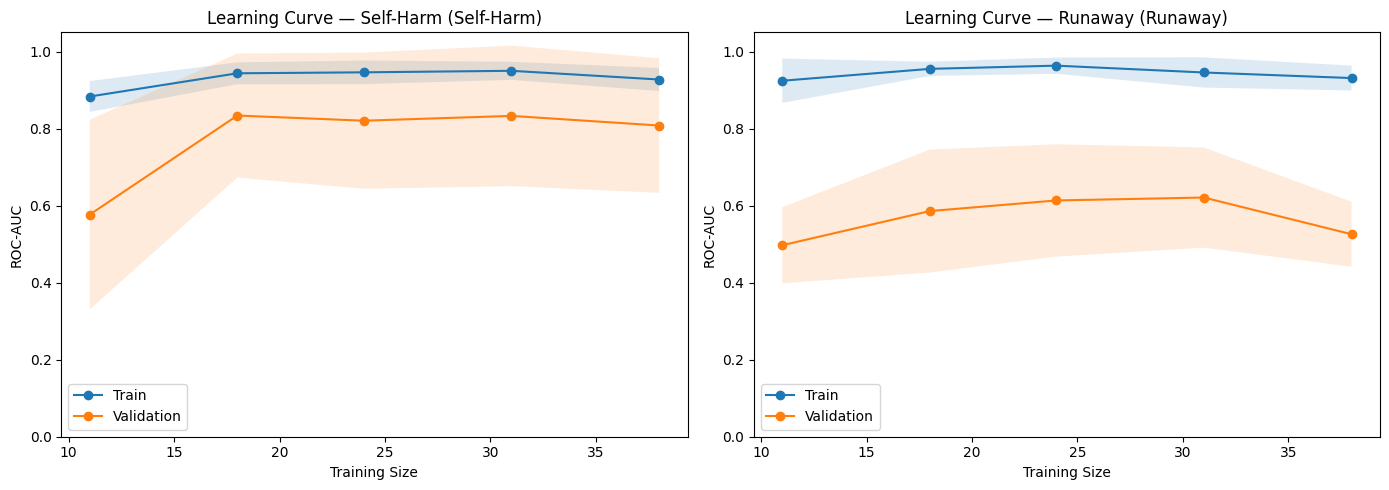

In [10]:
# 5b) Cross-validation on best models + learning curves
best_selfharm_name = selfharm_eval.iloc[0]["model"]
best_runaway_name = runaway_eval.iloc[0]["model"]
best_selfharm_model = selfharm_models[best_selfharm_name]
best_runaway_model = runaway_models[best_runaway_name]

print(f"Best self-harm model: {best_selfharm_name}")
print(f"Best runaway model: {best_runaway_name}")

# Cross-validation scores
for model, y_tr, name in [(best_selfharm_model, y_sh_train, "Self-Harm"),
                           (best_runaway_model, y_rw_train, "Runaway")]:
    cv_scores = cross_val_score(model, X_train, y_tr, cv=cv, scoring="roc_auc")
    print(f"\n{name} 5-fold CV AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"  Per-fold: {cv_scores}")

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, y_tr, name in [(axes[0], best_selfharm_model, y_sh_train, "Self-Harm"),
                                (axes[1], best_runaway_model, y_rw_train, "Runaway")]:
    train_sizes, train_scores, valid_scores = learning_curve(
        model, X_train, y_tr, cv=cv, scoring="roc_auc",
        n_jobs=-1, train_sizes=np.linspace(0.3, 1.0, 5),
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
    ax.plot(train_sizes, valid_scores.mean(axis=1), "o-", label="Validation")
    ax.fill_between(train_sizes, valid_scores.mean(axis=1) - valid_scores.std(axis=1),
                    valid_scores.mean(axis=1) + valid_scores.std(axis=1), alpha=0.15)
    ax.set_title(f"Learning Curve — {name} ({name})")
    ax.set_xlabel("Training Size")
    ax.set_ylabel("ROC-AUC")
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 6) Iterative Feature Selection via Permutation Feature Importance (Ch. 16)

Now that we have identified the best model architecture for each target in Step 5, we use **Permutation Feature Importance (PFI)** to iteratively prune low-value features.

### Algorithm
1. Start with the full variance-filtered feature set
2. For each target, compute PFI on the test set using the best model
3. Identify the bottom ~20% of features by PFI (features with near-zero or negative importance)
4. Drop those features from the training and test sets
5. Retrain **all** candidate models with GridSearchCV on the reduced feature set
6. Compare ROC-AUC — if no significant drop (< 1-2%), keep the reduced set
7. Repeat until dropping features causes a meaningful performance drop

Since this pipeline has **dual targets** (self-harm and runaway), we run separate PFI loops for each target. Each target may end up with a different final feature set.

In [11]:
# 6a) Iterative PFI feature selection — one loop per target

def iterative_pfi_selection(
    X_tr, X_te, y_tr, y_te, target_name,
    model_specs, cv, threshold=0.35, random_state=42,
    auc_drop_tolerance=0.02, max_iterations=10, drop_fraction=0.2,
):
    """
    Iteratively prune features using Permutation Feature Importance.
    
    At each iteration:
      1. Compute PFI on the test set using the current best model
      2. Identify the bottom `drop_fraction` of features
      3. Drop them
      4. Retrain ALL candidate models via GridSearchCV
      5. If AUC drops by more than `auc_drop_tolerance`, revert and stop
    
    Returns the final feature list, best model, and iteration history.
    """
    current_features = X_tr.columns.tolist()
    history = []
    
    # --- Initial baseline: train all models on full feature set ---
    baseline_auc = 0
    best_model = None
    best_model_name = None
    
    for name, pipe, grid in model_specs:
        gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr)
        proba = gs.best_estimator_.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else 0.5
        if auc > baseline_auc:
            baseline_auc = auc
            best_model = gs.best_estimator_
            best_model_name = name
    
    print(f"\n{'='*70}")
    print(f"ITERATIVE PFI — {target_name.upper()}")
    print(f"{'='*70}")
    print(f"Baseline: {len(current_features)} features, "
          f"best={best_model_name}, AUC={baseline_auc:.4f}")
    
    history.append({
        "iteration": 0,
        "n_features": len(current_features),
        "best_model": best_model_name,
        "test_auc": baseline_auc,
        "dropped": [],
    })
    
    prev_auc = baseline_auc
    
    for iteration in range(1, max_iterations + 1):
        # 1. Compute PFI on current best model
        perm = permutation_importance(
            best_model, X_te[current_features], y_te,
            n_repeats=30, random_state=random_state, scoring="roc_auc",
        )
        perm_df = pd.DataFrame({
            "feature": current_features,
            "importance": perm.importances_mean,
            "std": perm.importances_std,
        }).sort_values("importance", ascending=True)
        
        # 2. Identify bottom ~20% of features (at least 1, but never all)
        n_to_drop = max(1, int(len(current_features) * drop_fraction))
        # Only drop features with importance <= 0 or in the bottom fraction
        candidates_to_drop = perm_df.head(n_to_drop)
        # Safety: never drop below 2 features
        if len(current_features) - n_to_drop < 2:
            print(f"\nIteration {iteration}: Would drop below 2 features — stopping.")
            break
        
        features_to_drop = candidates_to_drop["feature"].tolist()
        reduced_features = [f for f in current_features if f not in features_to_drop]
        
        # 3. Retrain ALL candidate models on reduced feature set
        iter_best_auc = 0
        iter_best_model = None
        iter_best_name = None
        
        for name, pipe, grid in model_specs:
            gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True)
            gs.fit(X_tr[reduced_features], y_tr)
            proba = gs.best_estimator_.predict_proba(X_te[reduced_features])[:, 1]
            auc = roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else 0.5
            if auc > iter_best_auc:
                iter_best_auc = auc
                iter_best_model = gs.best_estimator_
                iter_best_name = name
        
        auc_change = iter_best_auc - prev_auc
        
        print(f"\nIteration {iteration}:")
        print(f"  Dropped {len(features_to_drop)} feature(s): {features_to_drop}")
        print(f"  Remaining: {len(reduced_features)} features")
        print(f"  Best model: {iter_best_name}, AUC: {iter_best_auc:.4f} "
              f"(change: {auc_change:+.4f})")
        
        # 4. Check if AUC drop exceeds tolerance
        if auc_change < -auc_drop_tolerance:
            print(f"  -> AUC dropped by {abs(auc_change):.4f} (> {auc_drop_tolerance}) — "
                  f"REVERTING to previous feature set.")
            break
        
        # Accept the reduction
        print(f"  -> Accepted (AUC change within tolerance)")
        current_features = reduced_features
        best_model = iter_best_model
        best_model_name = iter_best_name
        prev_auc = iter_best_auc
        
        history.append({
            "iteration": iteration,
            "n_features": len(current_features),
            "best_model": best_model_name,
            "test_auc": iter_best_auc,
            "dropped": features_to_drop,
        })
        
        # Stop if we're down to very few features
        if len(current_features) <= 3:
            print(f"  Down to {len(current_features)} features — stopping.")
            break
    
    print(f"\nFinal: {len(current_features)} features, "
          f"best={best_model_name}, AUC={prev_auc:.4f}")
    print(f"Final feature set: {current_features}")
    
    return current_features, best_model, best_model_name, prev_auc, history


# Run for SELF-HARM target
sh_final_features, sh_final_model, sh_final_model_name, sh_final_auc, sh_history = \
    iterative_pfi_selection(
        X_train, X_test, y_sh_train, y_sh_test, "Self-Harm",
        model_specs, cv, random_state=RANDOM_STATE,
    )

# Run for RUNAWAY target
rw_final_features, rw_final_model, rw_final_model_name, rw_final_auc, rw_history = \
    iterative_pfi_selection(
        X_train, X_test, y_rw_train, y_rw_test, "Runaway",
        model_specs, cv, random_state=RANDOM_STATE,
    )


ITERATIVE PFI — SELF-HARM
Baseline: 14 features, best=DecisionTree, AUC=1.0000



Iteration 1:
  Dropped 2 feature(s): ['age_at_admission', 'initial_risk_num']
  Remaining: 12 features
  Best model: LogReg, AUC: 1.0000 (change: +0.0000)
  -> Accepted (AUC change within tolerance)



Iteration 2:
  Dropped 2 feature(s): ['sub_cat_trafficked', 'has_special_needs']
  Remaining: 10 features
  Best model: LogReg, AUC: 1.0000 (change: +0.0000)
  -> Accepted (AUC change within tolerance)



Iteration 3:
  Dropped 2 feature(s): ['sub_cat_osaec', 'case_category_Abandoned']
  Remaining: 8 features
  Best model: LogReg, AUC: 1.0000 (change: +0.0000)
  -> Accepted (AUC change within tolerance)



Iteration 4:
  Dropped 1 feature(s): ['sub_cat_physical_abuse']
  Remaining: 7 features
  Best model: DecisionTree, AUC: 1.0000 (change: +0.0000)
  -> Accepted (AUC change within tolerance)


...


Iteration 7:
  Dropped 1 feature(s): ['is_pwd']
  Remaining: 4 features
  Best model: DecisionTree, AUC: 1.0000 (change: +0.0000)
  -> Accepted (AUC change within tolerance)



Iteration 8:
  Dropped 1 feature(s): ['case_category_Foundling']
  Remaining: 3 features
  Best model: LogReg, AUC: 1.0000 (change: +0.0000)
  -> Accepted (AUC change within tolerance)
  Down to 3 features — stopping.

Final: 3 features, best=LogReg, AUC=1.0000
Final feature set: ['sub_cat_sexual_abuse', 'case_category_Neglected', 'case_category_Surrendered']



ITERATIVE PFI — RUNAWAY
Baseline: 14 features, best=DecisionTree, AUC=0.5625



Iteration 1:
  Dropped 2 feature(s): ['initial_risk_num', 'case_category_Surrendered']
  Remaining: 12 features
  Best model: DecisionTree, AUC: 0.7031 (change: +0.1406)
  -> Accepted (AUC change within tolerance)



Iteration 2:
  Dropped 2 feature(s): ['sub_cat_trafficked', 'trauma_severity_score']
  Remaining: 10 features
  Best model: DecisionTree, AUC: 0.6406 (change: -0.0625)
  -> AUC dropped by 0.0625 (> 0.02) — REVERTING to previous feature set.

Final: 12 features, best=DecisionTree, AUC=0.7031
Final feature set: ['age_at_admission', 'trauma_severity_score', 'family_vulnerability_score', 'sub_cat_sexual_abuse', 'sub_cat_trafficked', 'sub_cat_osaec', 'sub_cat_physical_abuse', 'has_special_needs', 'is_pwd', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected']


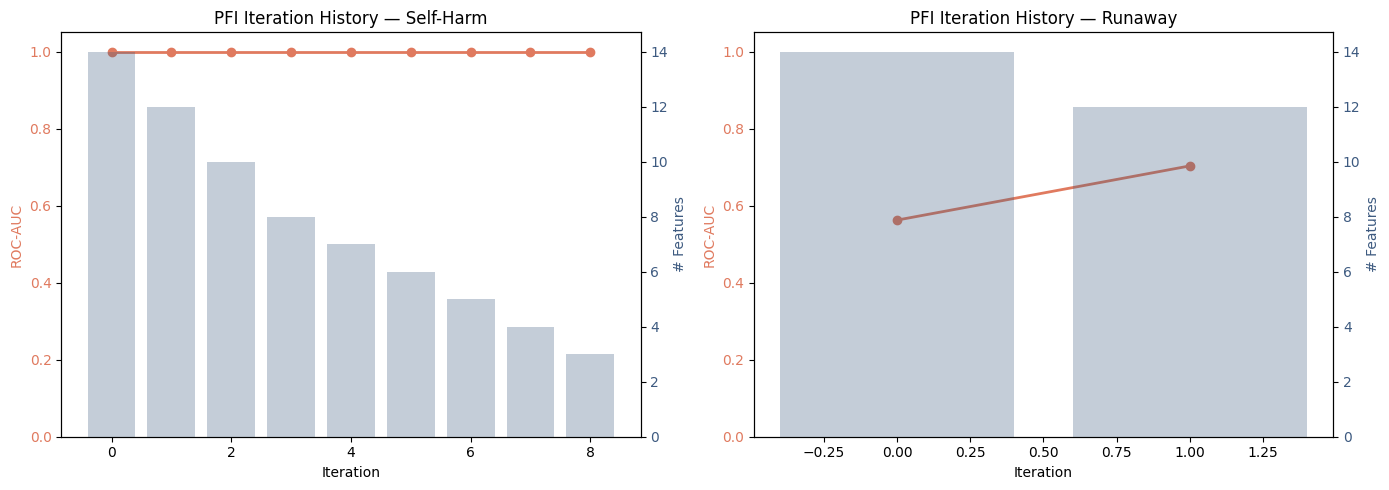

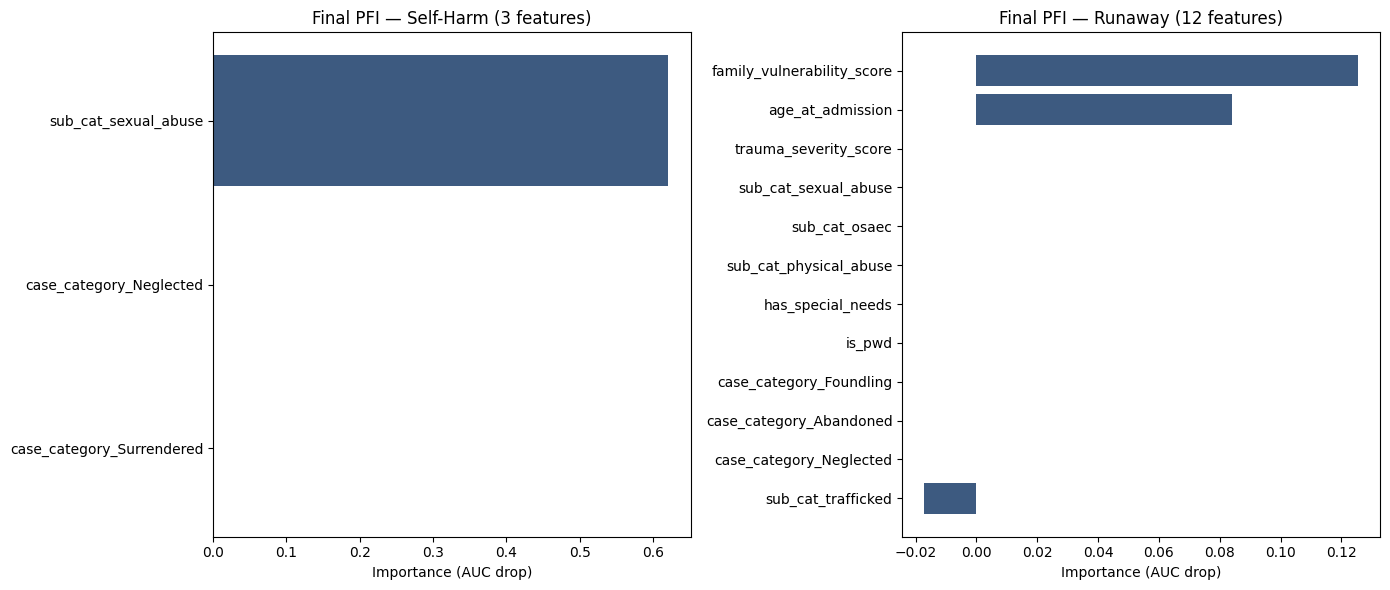


Final self-harm features (3): ['sub_cat_sexual_abuse', 'case_category_Neglected', 'case_category_Surrendered']
Final runaway features (12): ['age_at_admission', 'trauma_severity_score', 'family_vulnerability_score', 'sub_cat_sexual_abuse', 'sub_cat_trafficked', 'sub_cat_osaec', 'sub_cat_physical_abuse', 'has_special_needs', 'is_pwd', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected']
Union feature set (13): ['age_at_admission', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected', 'case_category_Surrendered', 'family_vulnerability_score', 'has_special_needs', 'is_pwd', 'sub_cat_osaec', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_trafficked', 'trauma_severity_score']

Final self-harm model: LogReg
Final runaway model: DecisionTree


In [12]:
# 6b) Visualize iteration history and final PFI

# --- Iteration history plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, name in [(axes[0], sh_history, "Self-Harm"), (axes[1], rw_history, "Runaway")]:
    iters = [h["iteration"] for h in hist]
    aucs = [h["test_auc"] for h in hist]
    n_feats = [h["n_features"] for h in hist]
    
    ax.plot(iters, aucs, "o-", color="#e07a5f", label="Test AUC", linewidth=2)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ROC-AUC", color="#e07a5f")
    ax.tick_params(axis="y", labelcolor="#e07a5f")
    ax.set_ylim(0, 1.05)
    
    ax2 = ax.twinx()
    ax2.bar(iters, n_feats, alpha=0.3, color="#3d5a80", label="# Features")
    ax2.set_ylabel("# Features", color="#3d5a80")
    ax2.tick_params(axis="y", labelcolor="#3d5a80")
    
    ax.set_title(f"PFI Iteration History — {name}")

plt.tight_layout()
plt.show()

# --- Final PFI bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, features, y_te, name in [
    (axes[0], sh_final_model, sh_final_features, y_sh_test, "Self-Harm"),
    (axes[1], rw_final_model, rw_final_features, y_rw_test, "Runaway"),
]:
    perm = permutation_importance(
        model, X_test[features], y_te,
        n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc",
    )
    perm_df = pd.DataFrame({
        "feature": features,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)
    
    ax.barh(perm_df["feature"], perm_df["importance"], color="#3d5a80")
    ax.set_xlabel("Importance (AUC drop)")
    ax.set_title(f"Final PFI — {name} ({len(features)} features)")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# --- Update best models to use final feature sets ---
# Retrain final models on their selected features for downstream use
best_selfharm_name = sh_final_model_name
best_runaway_name = rw_final_model_name
best_selfharm_model = sh_final_model
best_runaway_model = rw_final_model

# Update feature_cols for artifact saving — use union of both feature sets
# so the saved model can handle both targets
all_final_features = sorted(set(sh_final_features) | set(rw_final_features))

print(f"\nFinal self-harm features ({len(sh_final_features)}): {sh_final_features}")
print(f"Final runaway features ({len(rw_final_features)}): {rw_final_features}")
print(f"Union feature set ({len(all_final_features)}): {all_final_features}")
print(f"\nFinal self-harm model: {best_selfharm_name}")
print(f"Final runaway model: {best_runaway_name}")

## 7) Business Interpretation

### What the recall-precision trade-off means operationally

With threshold 0.35 (lower than the default 0.5):
- **High recall** means we catch most at-risk residents — critical for safety
- **Lower precision** means some residents are flagged who won't have incidents — staff do extra monitoring for those residents
- Given the ethical stakes (missing a self-harm case for a minor), this trade-off is strongly justified

### Test set caveat

With only 12 test samples (2-4 positive cases per target), individual metric estimates are unreliable. The 5-fold CV scores provide a more stable estimate of model quality. These models should be validated on new cohorts as the safehouse admits more residents.

### Explanatory decomposition

For interpretable odds ratios and coefficient-level analysis of *which intake characteristics drive risk*, see **Pipeline 5B (Incident Risk Drivers)**, which fits logistic regression models for both self-harm and runaway targets with EPV-constrained feature sets. Pipeline 5 tells staff *who* is at risk; Pipeline 5B tells them *why*.


## 9) Causal and Relationship Analysis

### Key findings from intake features

**Self-harm risk factors:**
- **Sexual abuse history** (`sub_cat_sexual_abuse`) is the strongest single predictor. Residents with sexual abuse backgrounds show dramatically higher self-harm rates (~67%). This aligns with clinical research on the link between sexual trauma and self-injurious behavior.
- **Initial risk level** (`initial_risk_num`) captures the intake assessment team's holistic judgment. Higher initial risk is associated with more incidents across both categories.
- **Trauma severity** (weighted composite) aggregates multiple trauma types. Higher severity indicates more complex trauma histories that elevate risk.

**Runaway risk factors:**
- **Trafficking history** (`sub_cat_trafficked`) is the strongest runaway predictor (~64% runaway rate). This makes clinical sense — trafficked minors may have been conditioned to flee or may be under external pressure to return.
- **Physical abuse** and **OSAEC** (online sexual abuse/exploitation of children) are also associated with elevated runaway risk.

### Causal vs. correlational

These intake features are **observed at admission** and precede any incidents temporally, which strengthens (but does not prove) directional claims:
- **Likely causal pathway:** Sexual abuse history -> psychological distress -> self-harm behavior. This is well-established in clinical literature.
- **Likely causal pathway:** Trafficking history -> external pressure/flight conditioning -> runaway attempts.
- **Correlational only:** Initial risk level is an *assessment* that may reflect the same underlying factors rather than an independent cause.

### Ethical considerations

- **False negatives are unacceptable** in this context — missing a self-harm risk for a vulnerable minor could have catastrophic consequences.
- **Model scores should inform, not replace, clinical judgment** — staff should use these as one input alongside their professional assessment.
- **Avoid deterministic labeling** — a high risk score does not mean an incident *will* happen. It means the profile is *associated with* elevated risk based on historical patterns.

### Explanatory decomposition

For odds ratios and coefficient-level interpretation of intake risk factors, see **Pipeline 5B (Incident Risk Drivers)**. That pipeline fits logistic regression with EPV-aware feature limits and provides defensible coefficient estimates for both self-harm and runaway targets.


## 10) Deployment Notes

- **Two models saved** as a combined bundle in `models/incident-early-warning/model.sav`: self-harm classifier + runaway classifier, each with its own PFI-selected feature set.
- **Intake-only features** — models can score a resident the moment they are admitted, before any counseling, health, or visitation data exists.
- **Separate feature sets** — each target uses its own PFI-selected features; the saved metadata records the union for the ETL pipeline.
- **Nightly inference** (`incident_early_warning/infer.py`) scores all active residents and writes **two rows per resident** to the `ml_predictions` table (one for self-harm risk, one for runaway risk). The `ml_prediction_history` table tracks how risk scores evolve as new data becomes available.
- **Score labels:** Critical (75-100), High (50-74), Medium (25-49), Low (0-24).
- **Web integration:** The backend queries `ml_predictions` for `model_name = 'incident-early-warning'` and serves per-resident risk scores via the ML predictions API. Risk scores are displayed on the **Resident Dashboard** in the admin interface, prominently visible to case managers alongside the resident's case details. Critical and High risk residents trigger visual alerts to ensure staff awareness. The dual scores (self-harm + runaway) help staff tailor monitoring protocols to the specific risk type.
- **Staff integration:** Risk scores should inform, not replace, clinical judgment. Staff should use these as one input alongside their professional assessment.
- **Retraining:** Re-run as new residents are admitted and incidents are recorded. Each new incident materially changes the training distribution given the small dataset (~60 residents).
- **Model monitoring:** Track the ratio of flagged residents who actually experience incidents (positive predictive value). If the model consistently over-flags (low PPV), consider raising the threshold above 0.35. If any at-risk resident is missed (false negative), investigate immediately and consider lowering the threshold further.

### Why 4 Model Families (Not 9-10)

This pipeline uses 4 model families (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) instead of the 9-10 used in other pipelines. This is intentional:

1. **Very small positive class sizes** (~12 self-harm events, ~17 runaway events) make complex models prone to overfitting. Simpler models with fewer hyperparameters are more stable.
2. **Interpretability matters here** — staff need to understand *why* a resident is flagged, not just that they are. Logistic Regression and Decision Trees provide this directly.
3. **Models like KNN, SVM, and Naive Bayes** were excluded because they either require more data to be reliable (KNN) or make distributional assumptions that don't hold well with binary intake features (Naive Bayes).
4. **Stacking and AdaBoost** were excluded because the base models already achieve high CV AUC with the small feature set, and adding complexity increases overfitting risk without meaningful performance gain.


In [13]:
# 10) Save artifacts — using PFI-selected models and feature sets

# Compute final metrics on the selected feature sets
sh_proba = best_selfharm_model.predict_proba(X_test[sh_final_features])[:, 1]
sh_pred = (sh_proba >= THRESHOLD).astype(int)
sh_recall = recall_score(y_sh_test, sh_pred, zero_division=0)
sh_precision = precision_score(y_sh_test, sh_pred, zero_division=0)
sh_f1 = f1_score(y_sh_test, sh_pred, zero_division=0)
sh_roc = roc_auc_score(y_sh_test, sh_proba) if len(np.unique(y_sh_test)) > 1 else 0.5

rw_proba = best_runaway_model.predict_proba(X_test[rw_final_features])[:, 1]
rw_pred = (rw_proba >= THRESHOLD).astype(int)
rw_recall = recall_score(y_rw_test, rw_pred, zero_division=0)
rw_precision = precision_score(y_rw_test, rw_pred, zero_division=0)
rw_f1 = f1_score(y_rw_test, rw_pred, zero_division=0)
rw_roc = roc_auc_score(y_rw_test, rw_proba) if len(np.unique(y_rw_test)) > 1 else 0.5

# Save model bundle (joblib)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
bundle = {
    "selfharm_model": best_selfharm_model,
    "runaway_model": best_runaway_model,
    "feature_list": all_final_features,
}
joblib.dump(bundle, MODEL_PATH)

# Save metadata + metrics to model.json (combined run log)
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "model_type": "dual_classifier",
    "features": all_final_features,
    "num_training_rows": len(X_train),
    "num_test_rows": len(X_test),
    "total_rows": len(X),
    "selfharm_metrics": {
        "selected_model": best_selfharm_name,
        "selected_features": sh_final_features,
        "n_features": len(sh_final_features),
        "recall": float(sh_recall),
        "precision": float(sh_precision),
        "f1": float(sh_f1),
        "roc_auc": float(sh_roc),
    },
    "runaway_metrics": {
        "selected_model": best_runaway_name,
        "selected_features": rw_final_features,
        "n_features": len(rw_final_features),
        "recall": float(rw_recall),
        "precision": float(rw_precision),
        "f1": float(rw_f1),
        "roc_auc": float(rw_roc),
    },
}

# Load existing runs or create new
if MODEL_RUNS_PATH.exists():
    with open(MODEL_RUNS_PATH, "r", encoding="utf-8") as f:
        combined = _json.load(f)
    if not isinstance(combined, dict) or not isinstance(combined.get("runs"), list):
        combined = {"model_name": MODEL_NAME, "runs": []}
else:
    combined = {"model_name": MODEL_NAME, "runs": []}

combined["runs"].append(run)
with open(MODEL_RUNS_PATH, "w", encoding="utf-8") as f:
    _json.dump(combined, f, indent=2)

print(f"Saved dual model bundle:")
print(f"  Self-harm: {best_selfharm_name} ({len(sh_final_features)} features)")
print(f"  Runaway: {best_runaway_name} ({len(rw_final_features)} features)")
print(f"  Union feature set: {len(all_final_features)} features")

Saved dual model bundle:
  Self-harm: LogReg (3 features)
  Runaway: DecisionTree (12 features)
  Union feature set: 13 features
